<a href="https://colab.research.google.com/github/Josue-Aldebaran-G-L/Reto-1-Modelado-Predictivo/blob/main/Reto_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Configuración Inicial

In [ ]:
# ═══════════════════════════════════════════════════════════════════════════
# CONFIGURACIÓN DE LA ESTACIÓN PALMER - NO MODIFICAR
# ═══════════════════════════════════════════════════════════════════════════

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Configuración visual
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 11
np.random.seed(42)

# Colores oficiales de cada especie (inspirados en sus características)
COLORES_ESPECIES = {
    'Adelie': '#FF6B6B',      # Rojo coral
    'Chinstrap': '#4ECDC4',   # Turquesa
    'Gentoo': '#45B7D1'       # Azul cielo
}

print("╔═══════════════════════════════════════════════════════════════╗")
print("║     🐧 ESTACIÓN PALMER - SISTEMA DE CLASIFICACIÓN v2.0 🐧     ║")
print("║                                                               ║")
print("║   Bibliotecas cargadas correctamente                          ║")
print("║   Modo: HUMANO VS MÁQUINA                                     ║")
print("║                                                               ║")
print("╚═══════════════════════════════════════════════════════════════╝")

╔═══════════════════════════════════════════════════════════════╗
║     🐧 ESTACIÓN PALMER - SISTEMA DE CLASIFICACIÓN v2.0 🐧     ║
║                                                               ║
║   Bibliotecas cargadas correctamente                          ║
║   Modo: HUMANO VS MÁQUINA                                     ║
║                                                               ║
╚═══════════════════════════════════════════════════════════════╝


In [ ]:
# ═══════════════════════════════════════════════════════════════════════════
# CARGAR DATOS DE CAMPO - Dataset Palmer Penguins
# ═══════════════════════════════════════════════════════════════════════════

# Cargar el dataset de pingüinos (viene con seaborn)
df_original = sns.load_dataset('penguins')

# Eliminar filas con valores nulos para simplificar
df = df_original.dropna().reset_index(drop=True)

print("📡 Transmisión recibida desde Estación Palmer...")
print("")
print(f"   📊 Registros de pingüinos cargados: {len(df)}")
print(f"   🏝️ Islas monitoreadas: {df['island'].nunique()}")
print(f"   🐧 Especies identificadas: {df['species'].nunique()}")
print("")
print("   Distribución por especie:")
for species in df['species'].unique():
    count = (df['species'] == species).sum()
    print(f"      • {species}: {count} individuos")

print("")
print("✅ Datos listos para análisis")

📡 Transmisión recibida desde Estación Palmer...

   📊 Registros de pingüinos cargados: 333
   🏝️ Islas monitoreadas: 3
   🐧 Especies identificadas: 3

   Distribución por especie:
      • Adelie: 146 individuos
      • Chinstrap: 68 individuos
      • Gentoo: 119 individuos

✅ Datos listos para análisis


#Parte 1

In [ ]:
print("Primeros 10 registros del campo:")
print("="*80)
df.head(10)

Primeros 10 registros del campo:


,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female
4,Adelie,Torgersen,39.3,20.6,190.0,3650.0,Male
5,Adelie,Torgersen,38.9,17.8,181.0,3625.0,Female
6,Adelie,Torgersen,39.2,19.6,195.0,4675.0,Male
7,Adelie,Torgersen,41.1,17.6,182.0,3200.0,Female
8,Adelie,Torgersen,38.6,21.2,191.0,3800.0,Male
9,Adelie,Torgersen,34.6,21.1,198.0,4400.0,Male


##Ejercicio 1.1

In [ ]:
print("Estadisticas descriptivas del dataset:")
print("="*80)
estadisticas = df.describe()
estadisticas

Estadisticas descriptivas del dataset:


,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
count,333.000000,333.000000,333.000000,333.000000
mean,43.992793,17.164865,200.966967,4207.057057
std,5.468668,1.969235,14.015765,805.215802
min,32.100000,13.100000,172.000000,2700.000000
25%,39.500000,15.600000,190.000000,3550.000000
50%,44.500000,17.300000,197.000000,4050.000000
75%,48.600000,18.700000,213.000000,4775.000000
max,59.600000,21.500000,231.000000,6300.000000


In [ ]:
print("¿Cuál es el rango de masa corporal (body_mass_g) de los pingüinos? (mínimo a máximo)")
print("="*80)
print(f"Masa mínima: {estadisticas['body_mass_g']['min']}")
print(f"Masa máxima: {estadisticas['body_mass_g']['max']}")
print(f"Rango de Masa: {estadisticas['body_mass_g']['max'] - estadisticas['body_mass_g']['min']}")

¿Cuál es el rango de masa corporal (body_mass_g) de los pingüinos? (mínimo a máximo)
Masa mínima: 2700.0
Masa máxima: 6300.0
Rango de Masa: 3600.0


In [ ]:
print("¿Cuál es la longitud promedio del pico (bill_length_mm)?")
print("="*80)
print(f"Longitud promedio: {df['bill_length_mm'].mean()}")

¿Cuál es la longitud promedio del pico (bill_length_mm)?
Longitud promedio: 43.99279279279279


In [ ]:
print("¿Cuál es la longitud promedio de la aleta (flipper_length_mm)?")
print("="*80)
print("Longitud promedio: ", df['flipper_length_mm'].mean())

¿Cuál es la longitud promedio de la aleta (flipper_length_mm)?
Longitud promedio:  200.96696696696696


##Ejercicio 1.2

In [ ]:
columnas_numericas = ['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g']

In [ ]:
df_by_species = df.groupby('species')[columnas_numericas].mean()
df_by_species.head(10)

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
species,,,,
Adelie,38.823973,18.347260,190.102740,3706.164384
Chinstrap,48.833824,18.420588,195.823529,3733.088235
Gentoo,47.568067,14.996639,217.235294,5092.436975


In [ ]:
for col in columnas_numericas:
  print(f"Variable: {col}")
  print("-"*80)

  for species in df_by_species.index:
    print(f"Especie: {species}    Promedio: {df_by_species.loc[species, col]}")

  print("\n")

Variable: bill_length_mm
--------------------------------------------------------------------------------
Especie: Adelie    Promedio: 38.82397260273973
Especie: Chinstrap    Promedio: 48.83382352941176
Especie: Gentoo    Promedio: 47.56806722689076


Variable: bill_depth_mm
--------------------------------------------------------------------------------
Especie: Adelie    Promedio: 18.3472602739726
Especie: Chinstrap    Promedio: 18.420588235294115
Especie: Gentoo    Promedio: 14.996638655462185


Variable: flipper_length_mm
--------------------------------------------------------------------------------
Especie: Adelie    Promedio: 190.1027397260274
Especie: Chinstrap    Promedio: 195.8235294117647
Especie: Gentoo    Promedio: 217.23529411764707


Variable: body_mass_g
--------------------------------------------------------------------------------
Especie: Adelie    Promedio: 3706.1643835616437
Especie: Chinstrap    Promedio: 3733.0882352941176
Especie: Gentoo    Promedio: 5092.4369

In [ ]:
print("¿Qué especie tiene el pico más largo en promedio?")
print("="*80)
print(f"La especie con el pico más largo en promedio es: {df_by_species['bill_length_mm'].idxmax()}")

¿Qué especie tiene el pico más largo en promedio?
La especie con el pico más largo en promedio es: Chinstrap


In [ ]:
print("¿Qué especie tiene las aletas más largas?")
print("="*80)
print(f"La especie con las aletas más largas es: {df_by_species['flipper_length_mm'].idxmax()}")

¿Qué especie tiene las aletas más largas?
La especie con las aletas más largas es: Gentoo


In [ ]:
print("¿Qué especie es la más pesada?")
print("="*80)
print(f"La especie más pesada es: {df_by_species['body_mass_g'].idxmax()}")

¿Qué especie es la más pesada?
La especie más pesada es: Gentoo


In [ ]:
print("¿Qué especie tiene el pico más profundo (bill_depth más alto)?")
print("="*80)
print(f"La especie con el pico más profundo es: {df_by_species['bill_depth_mm'].idxmax()}")

¿Qué especie tiene el pico más profundo (bill_depth más alto)?
La especie con el pico más profundo es: Chinstrap


#Parte 2

##Ejercicio 2.1

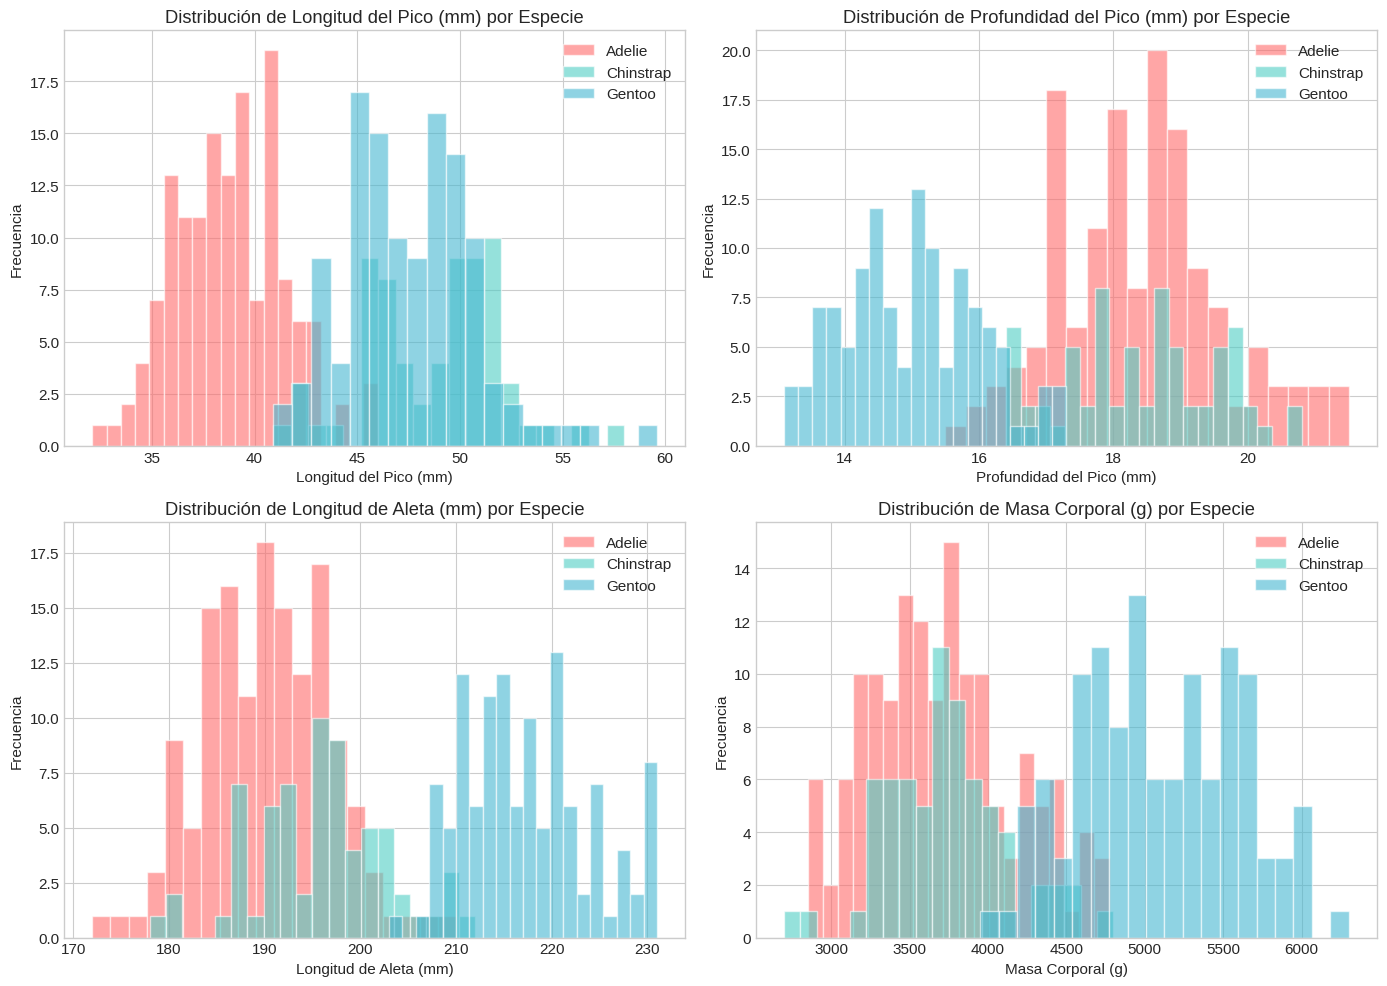

In [ ]:
# ═══════════════════════════════════════════════════════════════════════════
# VISUALIZACIÓN: Diferencias entre especies
# ═══════════════════════════════════════════════════════════════════════════

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

variables = ['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g']
titulos = ['Longitud del Pico (mm)', 'Profundidad del Pico (mm)',
           'Longitud de Aleta (mm)', 'Masa Corporal (g)']

for ax, var, titulo in zip(axes.flat, variables, titulos):
    for species in df['species'].unique():
        subset = df[df['species'] == species]
        ax.hist(subset[var], alpha=0.6, label=species,
                color=COLORES_ESPECIES[species], bins=20, edgecolor='white')
    ax.set_xlabel(titulo)
    ax.set_ylabel('Frecuencia')
    ax.legend()
    ax.set_title(f'Distribución de {titulo} por Especie')

plt.tight_layout()
plt.savefig('pinguinos_distribucion.png', dpi=150, bbox_inches='tight')
plt.show()

1. ¿Qué variable(s) usarás para separar primero una especie de las otras?
* Primero ocuparé `flipper_length_mm` ya que noto que esta es la que más logra separar a `Gentoo` muy fácilmente de `Chinstrap` y `Adelie`, después ocuparé `bill_length_mm` para poder distinguir entre `Chinstrap` y `Adelie`.
2. ¿Qué umbral(es) numérico(s) planeas usar? (ej.: "si aleta > 210")
* Primero, aplicaré la regla: `if flipper_length_mm > min_gentoo_threshold` para detectar si es `Gentoo`, en caso contrario, entonces pasaré a un segundo filtro; en este ocuparé `bill_length_mm < max_adelie_threshold` para detectar a los que son `Adelie`, en otro caso, será un `Chinstrap`.
* Para `min_gentoo_threshold` el valor está más o menos en 206 (mm) aproximadamente; para `max_adelie_threshold` el valor está 43 (mm) aproximadamente. Para mayor exactitud, planeó ocupar intervalos de confianza con 2σ para `min_gentoo_threshold` y para `max_adelie_threshold`.
3. ¿Cuál especie crees que será más fácil de identificar? ¿Por qué?
* `Gentoo`, ya que por sí solo noto que su distribución se separa muy fácilmente de los otros, salvo por algunos casos muy particulares, pero en general es el que tiene más diferencia con los otros y menos casos especiales.
4. ¿Cuál especie crees que será más difícil? ¿Por qué?
* `Chinstrap`, ya que en todas las gráficas se solapa con alguna de las otras dos especies.

##Ejercicio 2.2

In [ ]:
def calcular_valor_confianza(datos, confianza_sigma=3, tipo="inferior"):
  tipo = tipo.lower()

  media = np.mean(datos)
  std = np.std(datos, ddof=1)

  if(tipo == "inferior"):
    return media - (confianza_sigma * std)
  elif(tipo == "superior"):
    return media + (confianza_sigma * std)

  error = "No ingresó un tipo adecuado"
  raise ValueError(error)

In [ ]:
min_gentoo_threshold = calcular_valor_confianza(df[df['species'] == "Gentoo"]['flipper_length_mm'], confianza_sigma=2, tipo="inferior")
max_adelie_threshold = calcular_valor_confianza(df[df['species'] == "Adelie"]['bill_length_mm'], confianza_sigma=2, tipo="superior")

In [ ]:
print("Umbral minimo para especie Gentoo: ", min_gentoo_threshold)
print("Umbral maximo para especie Adelie: ", max_adelie_threshold)

Umbral minimo para especie Gentoo:  204.0644328988707
Umbral maximo para especie Adelie:  44.14916606437785


In [ ]:
def clasificador_humano(
    bill_length_mm,
    bill_depth_mm,
    flipper_length_mm,
    body_mass_g,
    min_gentoo_threshold=204.0644328988707,
    max_adelie_threshold=44.14916606437785):
  """
  Clasifica un pingüino basándose en reglas diseñadas por un humano.

  Parámetros:
  -----------
  bill_length_mm : float
    Longitud del pico en milímetros
  bill_depth_mm : float
    Profundidad del pico en milímetros
  flipper_length_mm : float
    Longitud de la aleta en milímetros
  body_mass_g : float
    Masa corporal en gramos
  min_gentoo_threshold : float
    Umbral mínimo para la especie Gentoo según confianza de 2 sigma
    en la distribución flipper_length_mm
  max_adelie_threshold : float
    Umbral máximo para la especie Adelie según confianza de 2 sigma
    en la distribución bill_length_mm

  Retorna:
  --------
  str : 'Adelie', 'Chinstrap', o 'Gentoo'
  """

  if(flipper_length_mm > min_gentoo_threshold):
    return 'Gentoo'
  else:
    if(bill_length_mm < max_adelie_threshold):
      return 'Adelie'
    else:
      return 'Chinstrap'

In [ ]:
# Prueba rápida de tu clasificador con algunos ejemplos
print("🧪 Prueba de tu clasificador humano:")
print("="*60)

# Casos de prueba (valores típicos de cada especie)
casos_prueba = [
    # [bill_length, bill_depth, flipper_length, body_mass, especie_real]
    [39.1, 18.7, 181, 3750, "Adelie"],
    [46.5, 17.9, 192, 3500, "Chinstrap"],
    [46.1, 13.2, 211, 4500, "Gentoo"],
]

print(f"{'Pico L':>8} {'Pico D':>8} {'Aleta':>8} {'Masa':>8} │ {'Real':>12} {'Tu Pred':>12} {'¿Correcto?':>12}")
print("-" * 80)

for caso in casos_prueba:
    pred = clasificador_humano(caso[0], caso[1], caso[2], caso[3])
    real = caso[4]
    correcto = "✅" if pred == real else "❌"
    print(f"{caso[0]:>8.1f} {caso[1]:>8.1f} {caso[2]:>8} {caso[3]:>8} │ {real:>12} {str(pred):>12} {correcto:>12}")

🧪 Prueba de tu clasificador humano:
  Pico L   Pico D    Aleta     Masa │         Real      Tu Pred   ¿Correcto?
--------------------------------------------------------------------------------
    39.1     18.7      181     3750 │       Adelie       Adelie            ✅
    46.5     17.9      192     3500 │    Chinstrap    Chinstrap            ✅
    46.1     13.2      211     4500 │       Gentoo       Gentoo            ✅


#Parte 3

##Parte 3.1

In [ ]:
X = df[['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g']]
y = df['species']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [ ]:
print(f"📊 División de datos:")
print(f"   Entrenamiento: {len(X_train)} pingüinos")
print(f"   Prueba: {len(X_test)} pingüinos")

📊 División de datos:
   Entrenamiento: 266 pingüinos
   Prueba: 67 pingüinos


##Parte 3.2

In [ ]:
predicciones_humano = []

In [ ]:
for idx, row in X_test.iterrows():
    pred = clasificador_humano(
        row['bill_length_mm'],
        row['bill_depth_mm'],
        row['flipper_length_mm'],
        row['body_mass_g']
    )
    predicciones_humano.append(pred)

In [ ]:
accuracy_humano = accuracy_score(y_test, predicciones_humano)

In [ ]:
print("╔═══════════════════════════════════════════════════════════════╗")
print("║           🧠 RESULTADOS DEL CLASIFICADOR HUMANO 🧠           ║")
print("╠═══════════════════════════════════════════════════════════════╣")
print(f"║   Accuracy: {accuracy_humano:.2%}                                            ║")
print(f"║   Aciertos: {int(accuracy_humano * len(y_test))} de {len(y_test)} pingüinos                                ║")
print("╚═══════════════════════════════════════════════════════════════╝")

╔═══════════════════════════════════════════════════════════════╗
║           🧠 RESULTADOS DEL CLASIFICADOR HUMANO 🧠           ║
╠═══════════════════════════════════════════════════════════════╣
║   Accuracy: 92.54%                                            ║
║   Aciertos: 62 de 67 pingüinos                                ║
╚═══════════════════════════════════════════════════════════════╝



📋 Matriz de Confusión - Clasificador Humano:


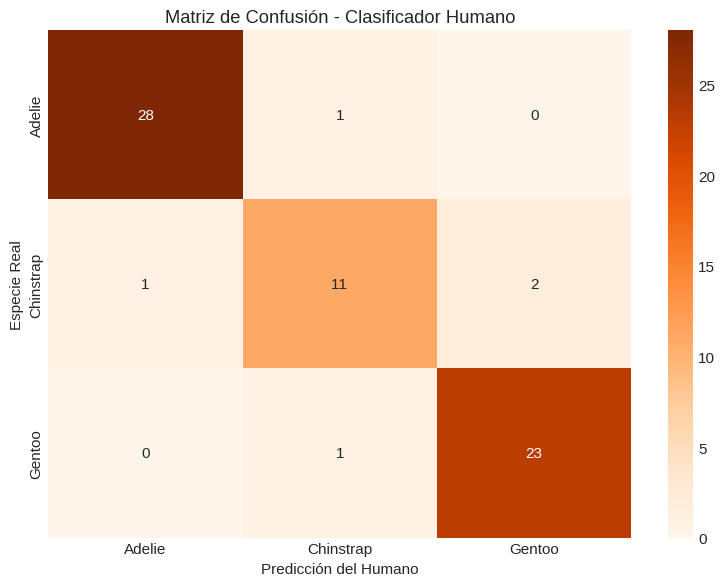


📊 Reporte Detallado:
              precision    recall  f1-score   support

      Adelie       0.97      0.97      0.97        29
   Chinstrap       0.85      0.79      0.81        14
      Gentoo       0.92      0.96      0.94        24

    accuracy                           0.93        67
   macro avg       0.91      0.90      0.91        67
weighted avg       0.92      0.93      0.92        67



In [ ]:
print("\n📋 Matriz de Confusión - Clasificador Humano:")
print("="*50)

cm_humano = confusion_matrix(y_test, predicciones_humano, labels=['Adelie', 'Chinstrap', 'Gentoo'])

plt.figure(figsize=(8, 6))
sns.heatmap(cm_humano, annot=True, fmt='d', cmap='Oranges',
            xticklabels=['Adelie', 'Chinstrap', 'Gentoo'],
            yticklabels=['Adelie', 'Chinstrap', 'Gentoo'])
plt.xlabel('Predicción del Humano')
plt.ylabel('Especie Real')
plt.title('Matriz de Confusión - Clasificador Humano')
plt.tight_layout()
plt.savefig('confusion_humano.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n📊 Reporte Detallado:")
print(classification_report(y_test, predicciones_humano))

1. ¿Qué especie clasificaste mejor?
* `Gentoo`, y `Adeile` fueron las mejores con tan solo un error en ambas, fue clasificado como `Chinstrap`
2. ¿Qué especie te dio más problemas? ¿Por qué crees que pasó?
* `Chinstrap`, justamente por el mismo argumento mencionado en la `Parte 2`, `Chinstrap` posee una distribución que está muy solapada con las otras dos clases y por ende es difícil saber de qué clase es.
3. ¿Cuántos pingüinos clasificaste incorrectamente?
* 5 pingüinos: 1 de `Gentoo`, 1 de `Adeile` y 3 de `Chinstrap`

#Parte 4

##Ejercicio 4.1

In [ ]:
modelo_ml = DecisionTreeClassifier(random_state=42)

In [ ]:
modelo_ml.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

In [ ]:
print("✅ Modelo de Machine Learning entrenado!")
print(f"   Profundidad del árbol: {modelo_ml.get_depth()}")
print(f"   Número de hojas: {modelo_ml.get_n_leaves()}")

✅ Modelo de Machine Learning entrenado!
   Profundidad del árbol: 5
   Número de hojas: 11


##Ejercicio 4.2

In [ ]:
predicciones_ml = modelo_ml.predict(X_test)

In [ ]:
accuracy_ml = accuracy_score(y_test, predicciones_ml)

In [ ]:
print("╔═══════════════════════════════════════════════════════════════╗")
print("║         🤖 RESULTADOS DEL CLASIFICADOR ML 🤖                 ║")
print("╠═══════════════════════════════════════════════════════════════╣")
print(f"║   Accuracy: {accuracy_ml:.2%}                                            ║")
print(f"║   Aciertos: {int(accuracy_ml * len(y_test))} de {len(y_test)} pingüinos                                ║")
print("╚═══════════════════════════════════════════════════════════════╝")

╔═══════════════════════════════════════════════════════════════╗
║         🤖 RESULTADOS DEL CLASIFICADOR ML 🤖                 ║
╠═══════════════════════════════════════════════════════════════╣
║   Accuracy: 95.52%                                            ║
║   Aciertos: 64 de 67 pingüinos                                ║
╚═══════════════════════════════════════════════════════════════╝



📋 Matriz de Confusión - Modelo ML:


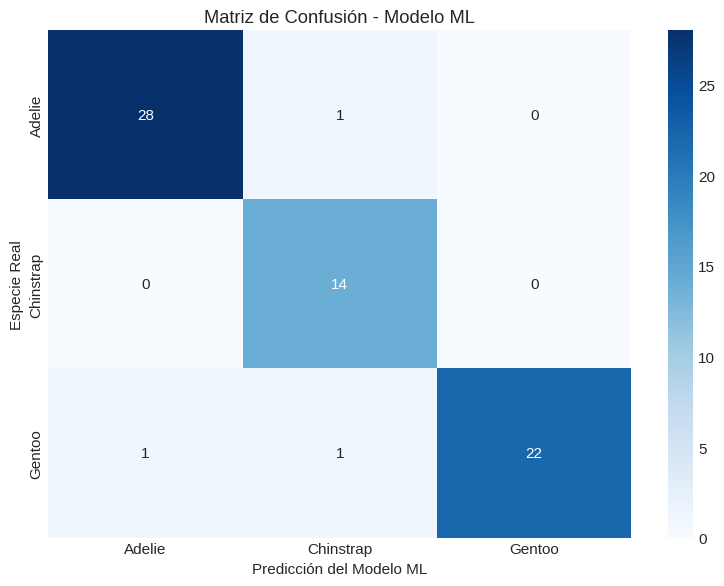


📊 Reporte Detallado:
              precision    recall  f1-score   support

      Adelie       0.97      0.97      0.97        29
   Chinstrap       0.88      1.00      0.93        14
      Gentoo       1.00      0.92      0.96        24

    accuracy                           0.96        67
   macro avg       0.95      0.96      0.95        67
weighted avg       0.96      0.96      0.96        67



In [ ]:
print("\n📋 Matriz de Confusión - Modelo ML:")
print("="*50)

cm_ml = confusion_matrix(y_test, predicciones_ml, labels=['Adelie', 'Chinstrap', 'Gentoo'])

plt.figure(figsize=(8, 6))
sns.heatmap(cm_ml, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Adelie', 'Chinstrap', 'Gentoo'],
            yticklabels=['Adelie', 'Chinstrap', 'Gentoo'])
plt.xlabel('Predicción del Modelo ML')
plt.ylabel('Especie Real')
plt.title('Matriz de Confusión - Modelo ML')
plt.tight_layout()
plt.savefig('confusion_ml.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n📊 Reporte Detallado:")
print(classification_report(y_test, predicciones_ml))

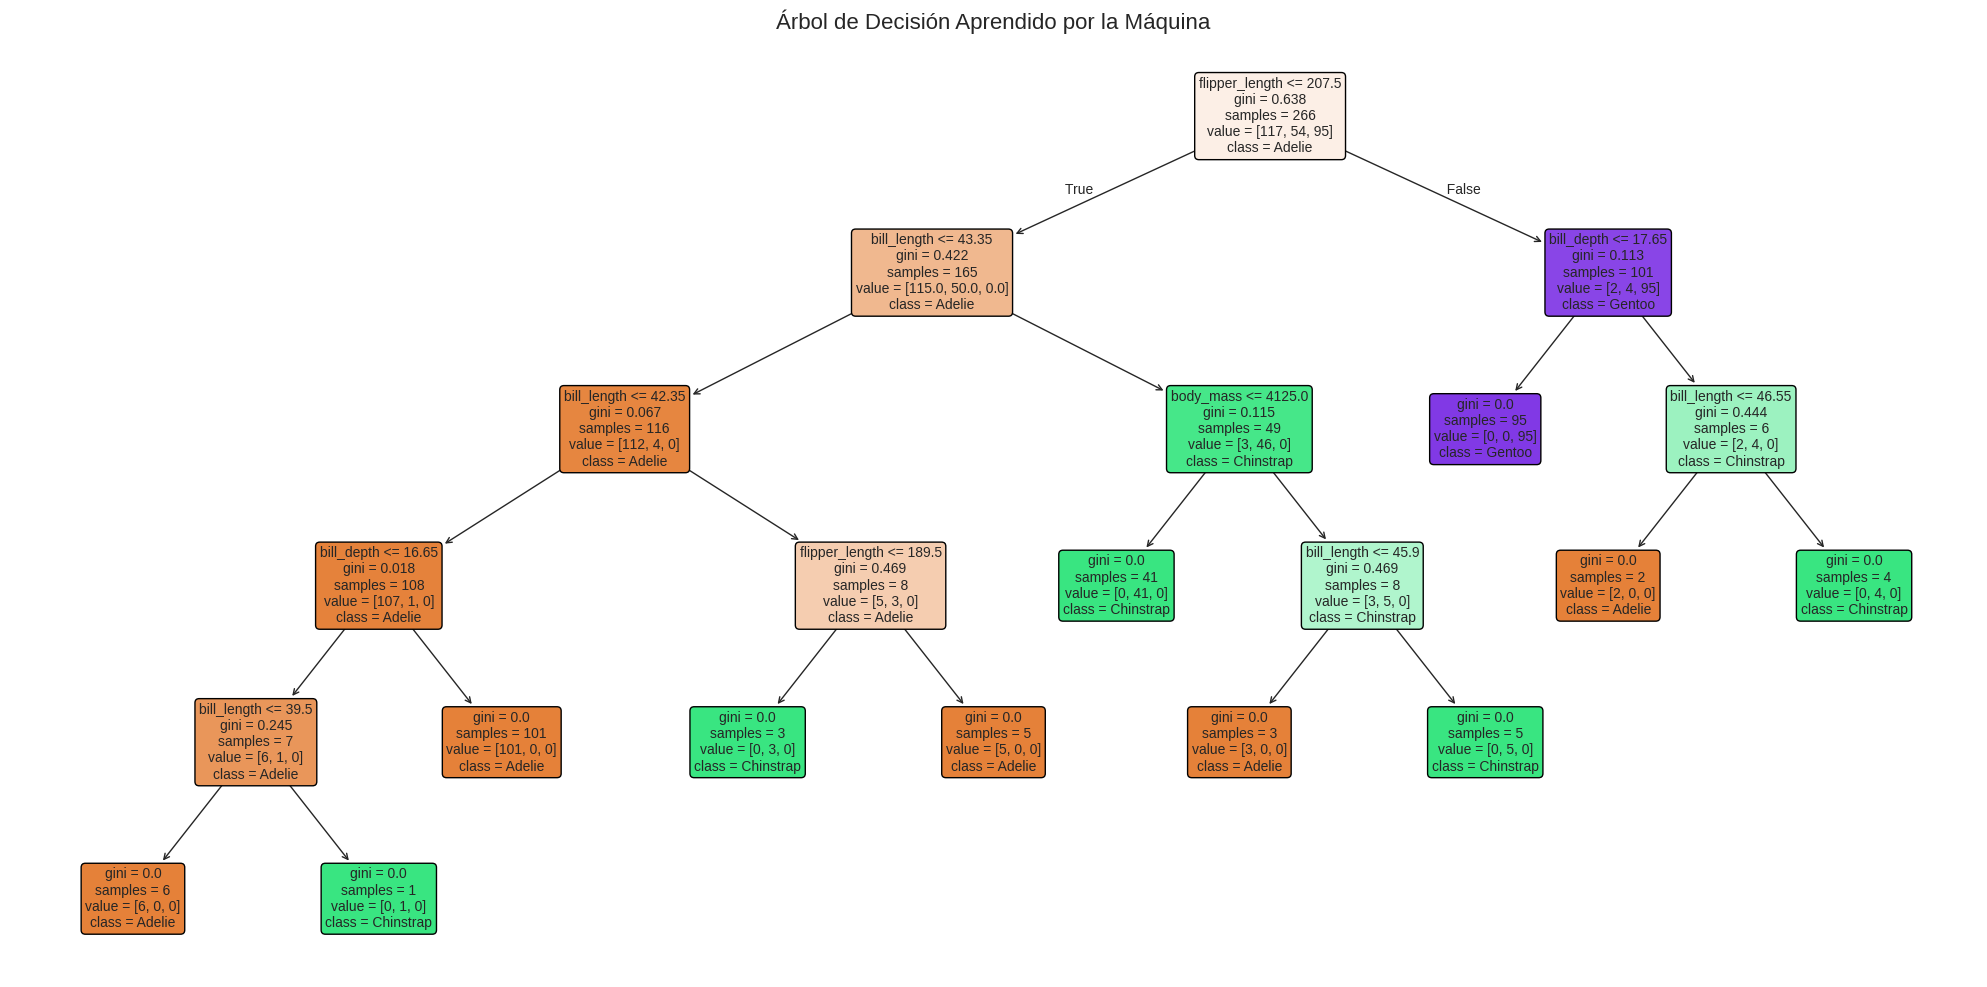

In [ ]:
from sklearn.tree import plot_tree

plt.figure(figsize=(20, 10))
plot_tree(
    modelo_ml,
    feature_names=['bill_length', 'bill_depth', 'flipper_length', 'body_mass'],
    class_names=['Adelie', 'Chinstrap', 'Gentoo'],
    filled=True,
    rounded=True,
    fontsize=10
)
plt.title('Árbol de Decisión Aprendido por la Máquina', fontsize=16)
plt.tight_layout()
plt.savefig('arbol_pinguinos.png', dpi=150, bbox_inches='tight')
plt.show()

#Parte 5

In [ ]:
# ═══════════════════════════════════════════════════════════════════════════
# COMPARACIÓN FINAL
# ═══════════════════════════════════════════════════════════════════════════

print("")
print("╔═══════════════════════════════════════════════════════════════════════════╗")
print("║                                                                           ║")
print("║            ⚔️  BATALLA FINAL: HUMANO VS MÁQUINA ⚔️                       ║")
print("║                                                                           ║")
print("╠═══════════════════════════════════════════════════════════════════════════╣")
print("║                                                                           ║")
print(f"║   🧠 CLASIFICADOR HUMANO:     {accuracy_humano:.2%} accuracy                            ║")
print(f"║      Aciertos: {int(accuracy_humano * len(y_test)):2d}/{len(y_test)} pingüinos                                            ║")
print("║                                                                           ║")
print(f"║   🤖 CLASIFICADOR ML:         {accuracy_ml:.2%} accuracy                            ║")
print(f"║      Aciertos: {int(accuracy_ml * len(y_test)):2d}/{len(y_test)} pingüinos                                            ║")
print("║                                                                           ║")
print("╠═══════════════════════════════════════════════════════════════════════════╣")

diferencia = accuracy_ml - accuracy_humano

if diferencia > 0:
    print("║                                                                           ║")
    print("║                     🏆 GANADOR: LA MÁQUINA 🏆                            ║")
    print(f"║                     Ventaja: +{diferencia:.2%}                                       ║")
    print("║                                                                           ║")
elif diferencia < 0:
    print("║                                                                           ║")
    print("║                     🏆 GANADOR: EL HUMANO 🏆                              ║")
    print(f"║                     Ventaja: +{-diferencia:.2%}                                   ║")
    print("║                                                                           ║")
else:
    print("║                                                                           ║")
    print("║                        🤝 EMPATE TÉCNICO 🤝                               ║")
    print("║                                                                           ║")

print("╚═══════════════════════════════════════════════════════════════════════════╝")


╔═══════════════════════════════════════════════════════════════════════════╗
║                                                                           ║
║            ⚔️  BATALLA FINAL: HUMANO VS MÁQUINA ⚔️                       ║
║                                                                           ║
╠═══════════════════════════════════════════════════════════════════════════╣
║                                                                           ║
║   🧠 CLASIFICADOR HUMANO:     92.54% accuracy                            ║
║      Aciertos: 62/67 pingüinos                                            ║
║                                                                           ║
║   🤖 CLASIFICADOR ML:         95.52% accuracy                            ║
║      Aciertos: 64/67 pingüinos                                            ║
║                                                                           ║
╠═══════════════════════════════════════════════════════════════════

/tmp/ipython-input-1290484777.py:32: UserWarning: Glyph 128039 (\N{PENGUIN}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipython-input-1290484777.py:33: UserWarning: Glyph 128039 (\N{PENGUIN}) missing from font(s) Liberation Sans.
  plt.savefig('batalla_final.png', dpi=150, bbox_inches='tight')
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128039 (\N{PENGUIN}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)


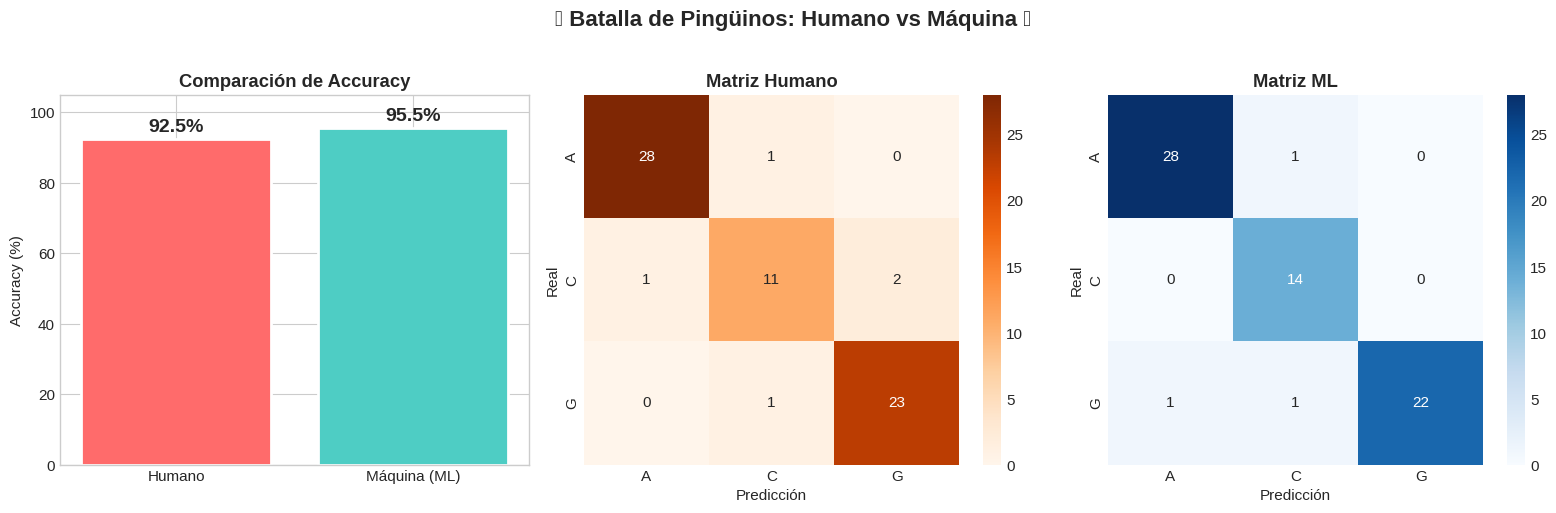

In [ ]:
# Gráfica comparativa
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Gráfica 1: Barras de accuracy
clasificadores = ['Humano', 'Máquina (ML)']
accuracies = [accuracy_humano * 100, accuracy_ml * 100]
colores_barras = ['#FF6B6B', '#4ECDC4']

bars = axes[0].bar(clasificadores, accuracies, color=colores_barras, edgecolor='white', linewidth=2)
axes[0].set_ylabel('Accuracy (%)')
axes[0].set_title('Comparación de Accuracy', fontweight='bold')
axes[0].set_ylim(0, 105)
for bar, acc in zip(bars, accuracies):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                f'{acc:.1f}%', ha='center', va='bottom', fontsize=14, fontweight='bold')

# Gráfica 2: Matrices de confusión lado a lado (Humano)
sns.heatmap(cm_humano, annot=True, fmt='d', cmap='Oranges', ax=axes[1],
            xticklabels=['A', 'C', 'G'], yticklabels=['A', 'C', 'G'])
axes[1].set_title('Matriz Humano', fontweight='bold')
axes[1].set_xlabel('Predicción')
axes[1].set_ylabel('Real')

# Gráfica 3: Matriz ML
sns.heatmap(cm_ml, annot=True, fmt='d', cmap='Blues', ax=axes[2],
            xticklabels=['A', 'C', 'G'], yticklabels=['A', 'C', 'G'])
axes[2].set_title('Matriz ML', fontweight='bold')
axes[2].set_xlabel('Predicción')
axes[2].set_ylabel('Real')

plt.suptitle('🐧 Batalla de Pingüinos: Humano vs Máquina 🐧', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('batalla_final.png', dpi=150, bbox_inches='tight')
plt.show()

##Ejercicio 5.1

In [ ]:
# Crear DataFrame con resultados
resultados = X_test.copy()
resultados['especie_real'] = y_test.values
resultados['pred_humano'] = predicciones_humano
resultados['pred_ml'] = predicciones_ml
resultados['error_humano'] = resultados['especie_real'] != resultados['pred_humano']
resultados['error_ml'] = resultados['especie_real'] != resultados['pred_ml']

# Mostrar errores del humano
errores_humano = resultados[resultados['error_humano']]
print(f"❌ Errores del clasificador HUMANO ({len(errores_humano)} casos):")
print("="*80)
if len(errores_humano) > 0:
    print(errores_humano[['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm',
                          'body_mass_g', 'especie_real', 'pred_humano']].to_string())
else:
    print("¡Ningún error! 🎉")

❌ Errores del clasificador HUMANO (5 casos):
     bill_length_mm  bill_depth_mm  flipper_length_mm  body_mass_g especie_real pred_humano
168            43.2           16.6              187.0       2900.0    Chinstrap      Adelie
14             46.0           21.5              194.0       4200.0       Adelie   Chinstrap
310            48.4           14.4              203.0       4625.0       Gentoo   Chinstrap
206            51.9           19.5              206.0       3950.0    Chinstrap      Gentoo
175            52.8           20.0              205.0       4550.0    Chinstrap      Gentoo


In [ ]:
# Mostrar errores de la máquina
errores_ml = resultados[resultados['error_ml']]
print(f"\n❌ Errores del clasificador ML ({len(errores_ml)} casos):")
print("="*80)
if len(errores_ml) > 0:
    print(errores_ml[['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm',
                      'body_mass_g', 'especie_real', 'pred_ml']].to_string())
else:
    print("¡Ningún error! 🎉")


❌ Errores del clasificador ML (3 casos):
     bill_length_mm  bill_depth_mm  flipper_length_mm  body_mass_g especie_real    pred_ml
245            45.1           14.5              207.0       5050.0       Gentoo     Adelie
14             46.0           21.5              194.0       4200.0       Adelie  Chinstrap
310            48.4           14.4              203.0       4625.0       Gentoo  Chinstrap


##Ejercicio 5.2

1. ¿Quién ganó la batalla y por cuánto?
* La Máquina me superó por 2 aciertos (5 errores vs. 3 errores) y por 3% de accuracy.
2. ¿Qué errores cometiste que la máquina no cometió? (o viceversa)
* 3 errores en particular en `Chinstrap`, la máquina no cometió ninguno de estos; sin embargo, en `Gentoo` yo solo cometí 1 error y la máquina cometió 2; por último, en `Adelie`, cometimos exactamente el mismo error.
3. ¿Las reglas del árbol de decisión se parecen a las tuyas? ¿Usó las mismas variables?
* Los primeros 2 niveles, sí, muy probablemente esto se deba ya que como mencioné previamente, se trate de un criterio el cual si está muy marcado y, por ende, es fácil decidir a partir de este mismo al menos para un nivel inicial.
4. ¿Cuál es la principal ventaja de usar machine learning sobre reglas manuales?
* Logra aprender patrones complejos y muchos más niveles que el ser humano no es capaz de ver a grandes rasgos, por lo que genera reglas más complejas para esto mismo.
5. ¿Qué harías diferente si pudieras volver a diseñar tus reglas?
* Añadir un tercer nivel, en este caso más enfocado a `Chinstrap` ya que parece ser una especie más complicada de tratar.

#BONUS

##Nuevo Clasificador 1

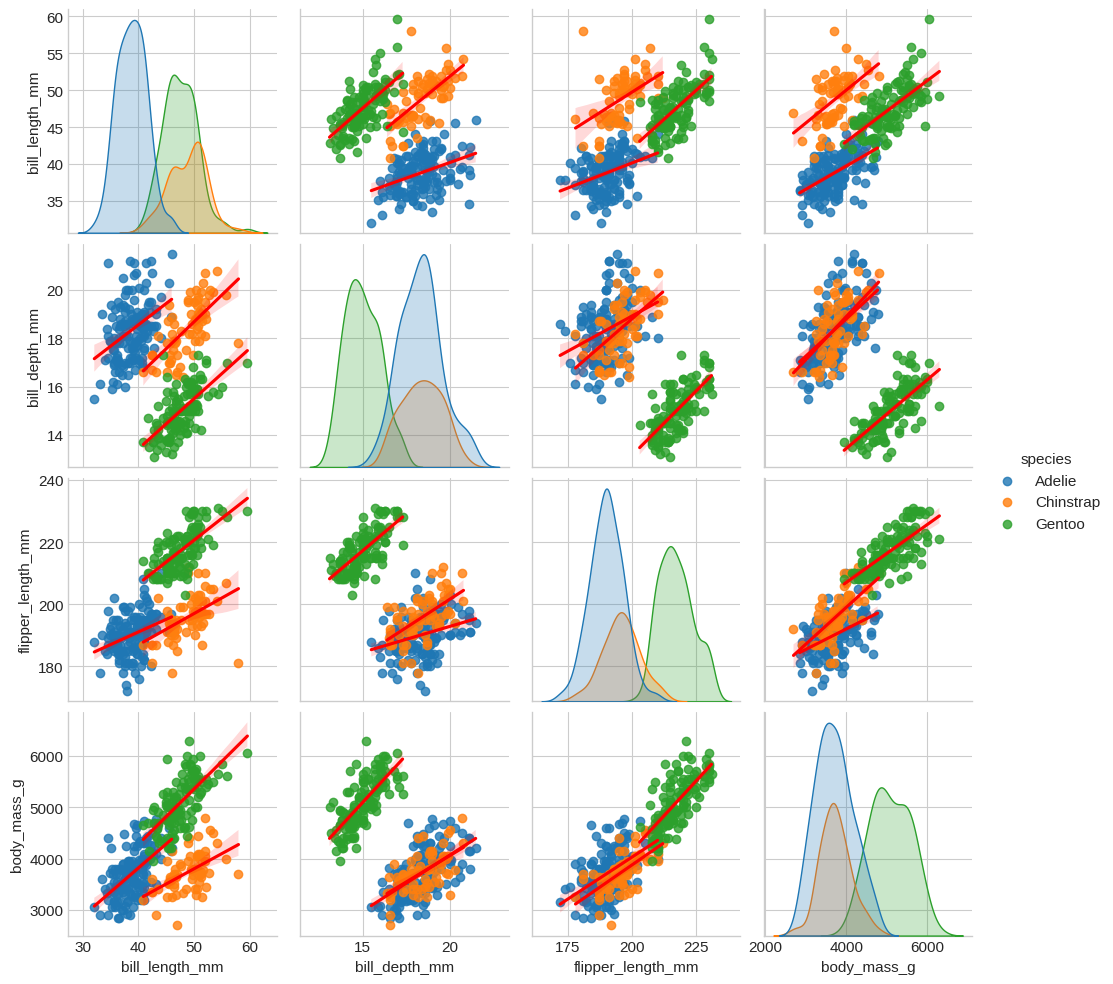

In [ ]:
sns.pairplot(df, hue='species', kind='reg', plot_kws={'line_kws':{'color':'red'}})

Podemos notar que la comparación entre `flipper_length_mm`y `bill_depth_mm` parece indicar dos umbrales prescisos en los que:
`flipper_length_mm > 200 and bill_depth_mm < 18` indican que pertenecen exactamente a la clase `Gentoo`, generaremos un arbol de prueba para esto.

In [ ]:
def clasificador_humano_prueba_1(
    bill_length_mm,
    bill_depth_mm,
    flipper_length_mm,
    body_mass_g):
  """
  Clasifica un pingüino basándose en reglas diseñadas por un humano.

  Parámetros:
  -----------
  bill_length_mm : float
    Longitud del pico en milímetros
  bill_depth_mm : float
    Profundidad del pico en milímetros
  flipper_length_mm : float
    Longitud de la aleta en milímetros
  body_mass_g : float
    Masa corporal en gramos

  Retorna:
  --------
  str : 'Adelie', 'Chinstrap', o 'Gentoo'
  """

  if(flipper_length_mm > 200):
    if(bill_depth_mm < 18):
      return 'Gentoo'
    else:
      return 'Chinstrap'
  else:
    return 'Chinstrap'

In [ ]:
predicciones_humano_prueba_1 = []

In [ ]:
for idx, row in X_test.iterrows():
    pred = clasificador_humano_prueba_1(
        row['bill_length_mm'],
        row['bill_depth_mm'],
        row['flipper_length_mm'],
        row['body_mass_g']
    )
    predicciones_humano_prueba_1.append(pred)

In [ ]:
accuracy_humano_prueba_1 = accuracy_score(y_test, predicciones_humano_prueba_1)


📋 Matriz de Confusión - Clasificador Humano Prueba 1:


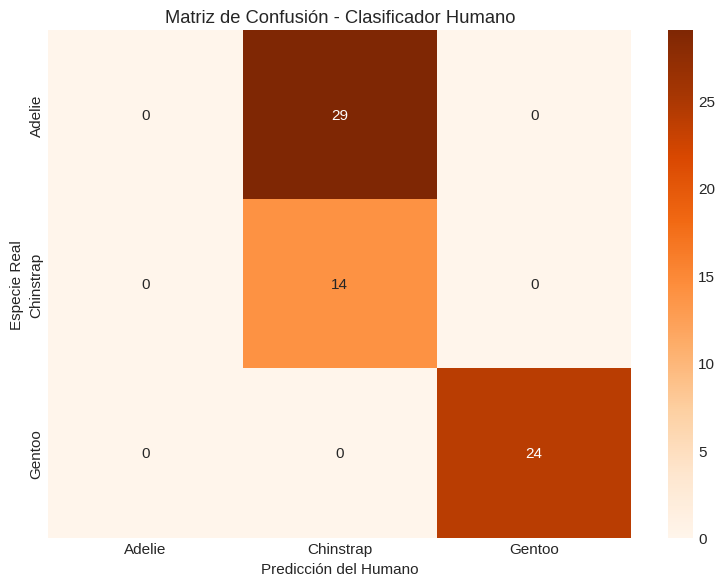


📊 Reporte Detallado:
              precision    recall  f1-score   support

      Adelie       0.00      0.00      0.00        29
   Chinstrap       0.33      1.00      0.49        14
      Gentoo       1.00      1.00      1.00        24

    accuracy                           0.57        67
   macro avg       0.44      0.67      0.50        67
weighted avg       0.43      0.57      0.46        67



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
print("\n📋 Matriz de Confusión - Clasificador Humano Prueba 1:")
print("="*50)

cm_humano_prueba_1 = confusion_matrix(y_test, predicciones_humano_prueba_1, labels=['Adelie', 'Chinstrap', 'Gentoo'])

plt.figure(figsize=(8, 6))
sns.heatmap(cm_humano_prueba_1, annot=True, fmt='d', cmap='Oranges',
            xticklabels=['Adelie', 'Chinstrap', 'Gentoo'],
            yticklabels=['Adelie', 'Chinstrap', 'Gentoo'])
plt.xlabel('Predicción del Humano')
plt.ylabel('Especie Real')
plt.title('Matriz de Confusión - Clasificador Humano')
plt.tight_layout()
plt.savefig('confusion_humano_prueba_1.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n📊 Reporte Detallado:")
print(classification_report(y_test, predicciones_humano_prueba_1))

Notamos que la clase `Gentoo` la clasifica perfectamente, ahora nos dedicaremos exclusivamente a las otras 2 clases.

##Nuevo Clasificador 2

In [ ]:
df_pruebas = df[df["species"] != "Gentoo"]

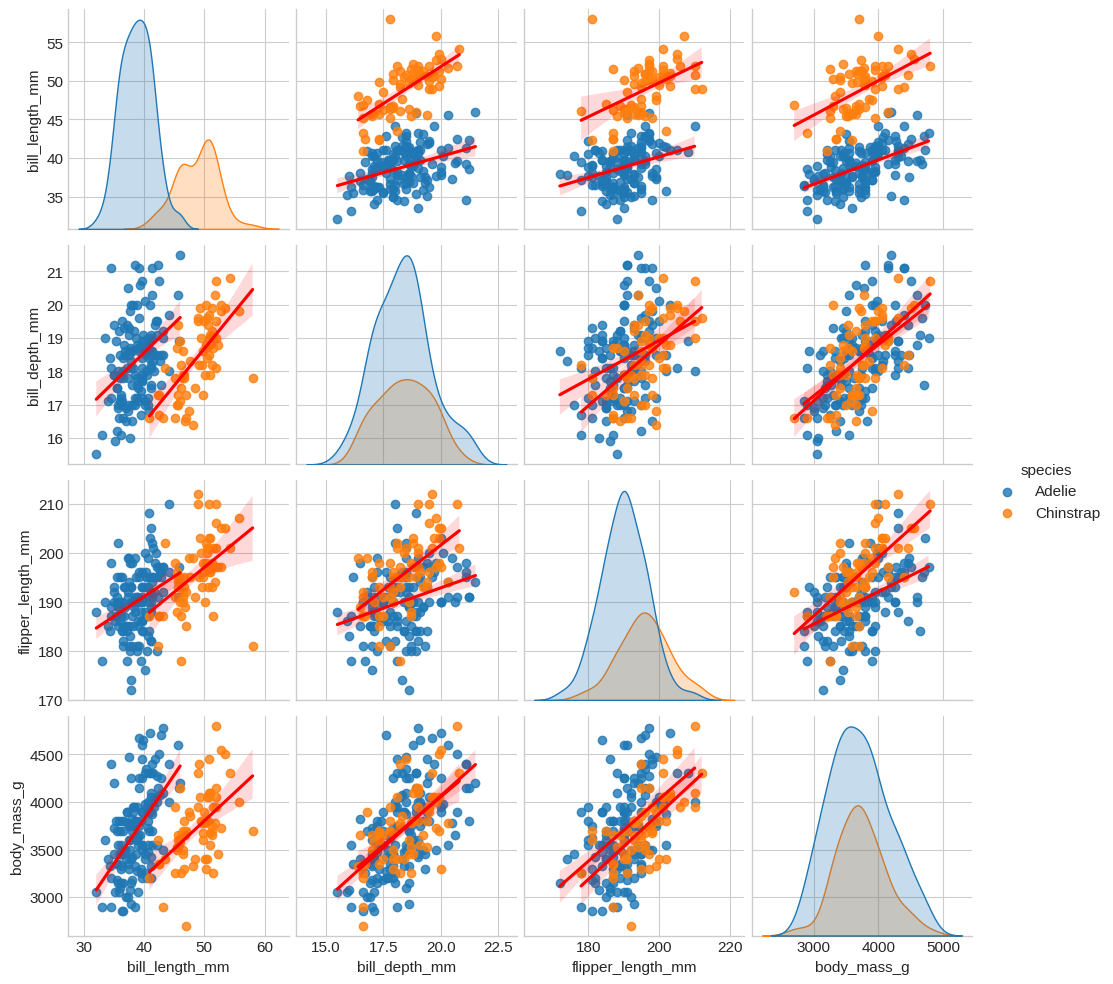

In [ ]:
sns.pairplot(df_pruebas, hue='species', kind='reg', plot_kws={'line_kws':{'color':'red'}})

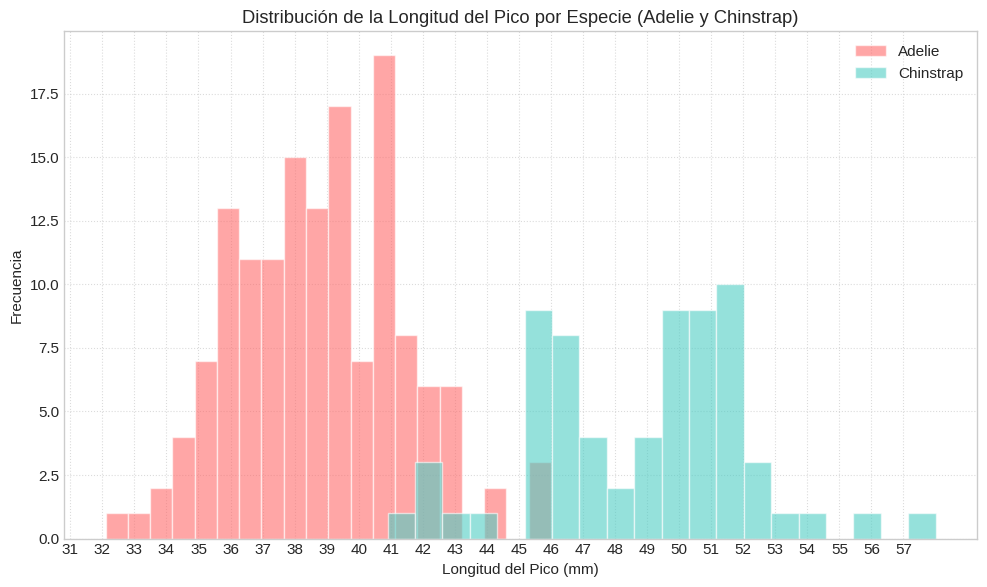

In [ ]:
plt.figure(figsize=(10, 6))

species_en_df_pruebas = df_pruebas['species'].unique()

for species in species_en_df_pruebas:
    subset = df_pruebas[df_pruebas['species'] == species]
    plt.hist(subset['bill_length_mm'], alpha=0.6, label=species,
             color=COLORES_ESPECIES[species], bins=20, edgecolor='white')

plt.xlabel('Longitud del Pico (mm)')
plt.ylabel('Frecuencia')
plt.xticks(range(
    int(df_pruebas['bill_length_mm'].min())-1,
    int(df_pruebas['bill_length_mm'].max()),
    1))
plt.title('Distribución de la Longitud del Pico por Especie (Adelie y Chinstrap)')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.7, which='both') # Cuadrícula más específica
plt.tight_layout()
plt.show()

Para `bill_length_mm` notamos que la zona de conflicto está entre 40 y 46. Con esto podemos mejorar el algortimos a:
1. Si `bill_length_mm < 40` entonces: `Adelie`
2. Si no, si `bill_length_mm > 46` entonces: `Chinstrap`
3. Sino: `?`

In [ ]:
df_pruebas = df[(df["species"] != "Gentoo") & (df["bill_length_mm"] >= 40) & (df["bill_length_mm"] <= 46)]

In [ ]:
len(df_pruebas)

65

In [ ]:
df_pruebas['species'].value_counts()

,count
species,
Adelie,50
Chinstrap,15


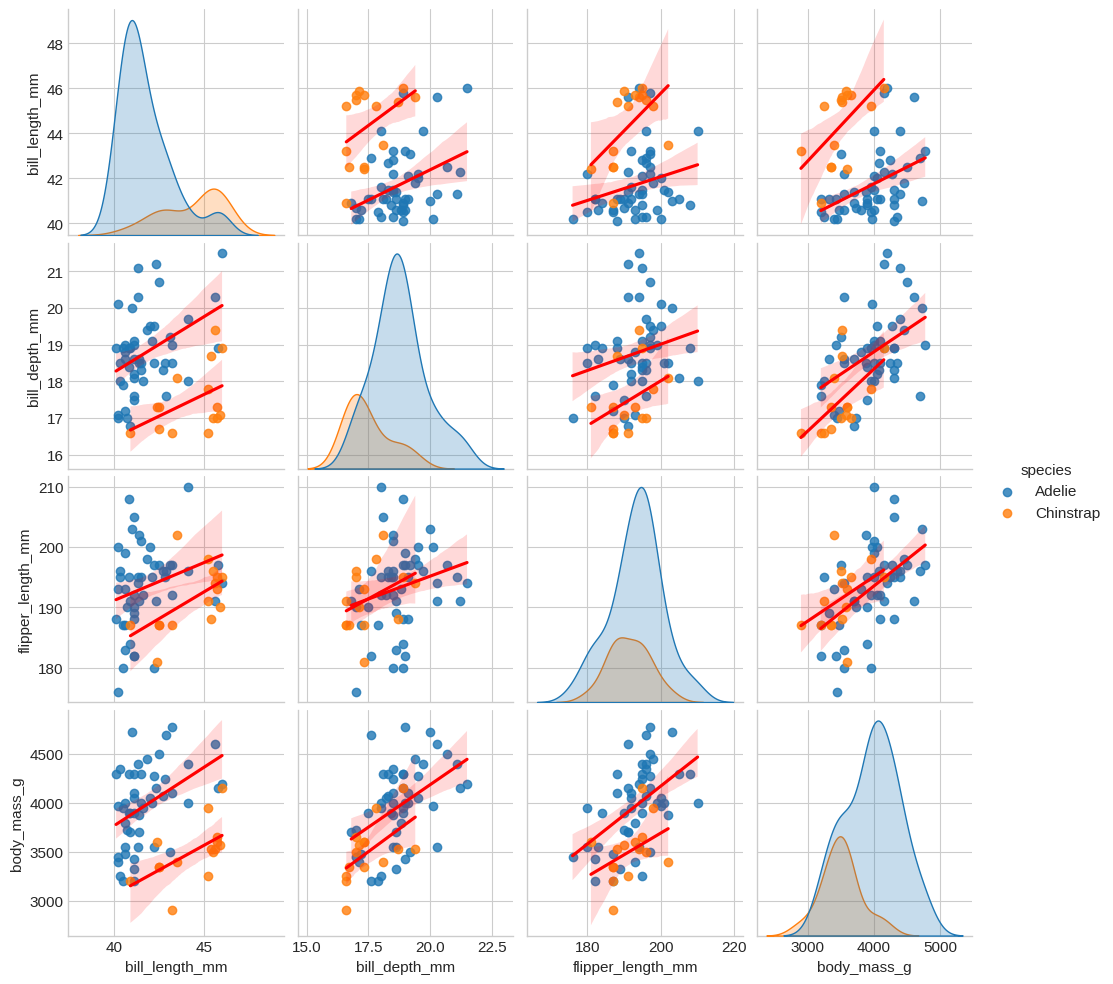

In [ ]:
sns.pairplot(df_pruebas, hue='species', kind='reg', plot_kws={'line_kws':{'color':'red'}})

Notamos que la zona de conflicto está mayormente dominada por `Adelie` y,además, no encontramos alguna forma en particular de distinguir ambas entre sí, por lo que se apostará por `Adelie`, con esto, tenemos el algoritmo de la forma:
1. Si `bill_length_mm > 46` entonces: `Chinstrap`
2. Sino: `Adelie`

In [ ]:
def clasificador_humano_prueba_2(
    bill_length_mm,
    bill_depth_mm,
    flipper_length_mm,
    body_mass_g):
  """
  Clasifica un pingüino basándose en reglas diseñadas por un humano.

  Parámetros:
  -----------
  bill_length_mm : float
    Longitud del pico en milímetros
  bill_depth_mm : float
    Profundidad del pico en milímetros
  flipper_length_mm : float
    Longitud de la aleta en milímetros
  body_mass_g : float
    Masa corporal en gramos

  Retorna:
  --------
  str : 'Adelie', 'Chinstrap', o 'Gentoo'
  """

  if(flipper_length_mm > 200):
    if(bill_depth_mm < 18):
      return 'Gentoo'
    else:
      if bill_length_mm > 46:
        return 'Chinstrap'
      else:
        return 'Adelie'
  else:
    if bill_length_mm > 46:
      return 'Chinstrap'
    else:
      return 'Adelie'

In [ ]:
predicciones_humano_prueba_2 = []

In [ ]:
for idx, row in X_test.iterrows():
    pred = clasificador_humano_prueba_2(
        row['bill_length_mm'],
        row['bill_depth_mm'],
        row['flipper_length_mm'],
        row['body_mass_g']
    )
    predicciones_humano_prueba_2.append(pred)

In [ ]:
accuracy_humano_prueba_2 = accuracy_score(y_test, predicciones_humano_prueba_2)


📋 Matriz de Confusión - Clasificador Humano Prueba 2:


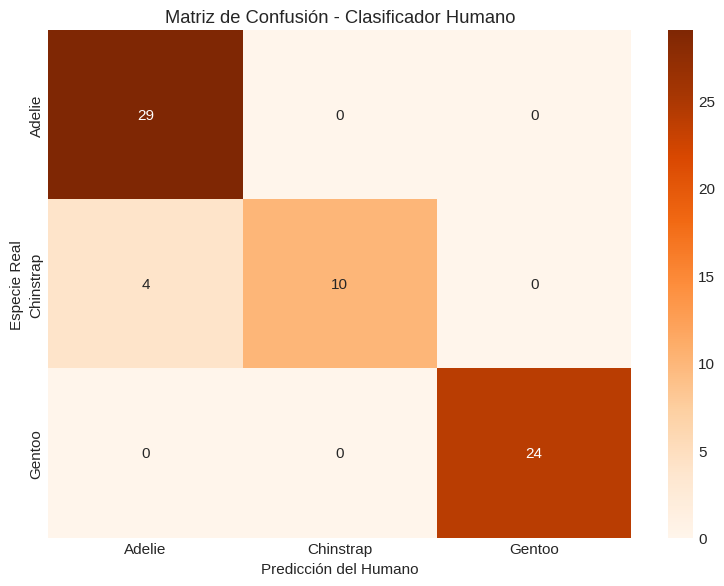


📊 Reporte Detallado:
              precision    recall  f1-score   support

      Adelie       0.88      1.00      0.94        29
   Chinstrap       1.00      0.71      0.83        14
      Gentoo       1.00      1.00      1.00        24

    accuracy                           0.94        67
   macro avg       0.96      0.90      0.92        67
weighted avg       0.95      0.94      0.94        67



In [ ]:
print("\n📋 Matriz de Confusión - Clasificador Humano Prueba 2:")
print("="*50)

cm_humano_prueba_2 = confusion_matrix(y_test, predicciones_humano_prueba_2, labels=['Adelie', 'Chinstrap', 'Gentoo'])

plt.figure(figsize=(8, 6))
sns.heatmap(cm_humano_prueba_2, annot=True, fmt='d', cmap='Oranges',
            xticklabels=['Adelie', 'Chinstrap', 'Gentoo'],
            yticklabels=['Adelie', 'Chinstrap', 'Gentoo'])
plt.xlabel('Predicción del Humano')
plt.ylabel('Especie Real')
plt.title('Matriz de Confusión - Clasificador Humano')
plt.tight_layout()
plt.savefig('confusion_humano_prueba_2.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n📊 Reporte Detallado:")
print(classification_report(y_test, predicciones_humano_prueba_2))

##Nuevo Clasificador 3

Ajustaremos la condición `bill_length_mm > 46` a `bill_length_mm > 45` ya que parece dar un mejor resultado.

In [ ]:
def clasificador_humano_prueba_3(
    bill_length_mm,
    bill_depth_mm,
    flipper_length_mm,
    body_mass_g):
  """
  Clasifica un pingüino basándose en reglas diseñadas por un humano.

  Parámetros:
  -----------
  bill_length_mm : float
    Longitud del pico en milímetros
  bill_depth_mm : float
    Profundidad del pico en milímetros
  flipper_length_mm : float
    Longitud de la aleta en milímetros
  body_mass_g : float
    Masa corporal en gramos

  Retorna:
  --------
  str : 'Adelie', 'Chinstrap', o 'Gentoo'
  """

  if(flipper_length_mm > 200):
    if(bill_depth_mm < 18):
      return 'Gentoo'
    else:
      if bill_length_mm > 45:
        return 'Chinstrap'
      else:
        return 'Adelie'
  else:
    if bill_length_mm > 45:
      return 'Chinstrap'
    else:
      return 'Adelie'

In [ ]:
predicciones_humano_prueba_3 = []

In [ ]:
for idx, row in X_test.iterrows():
    pred = clasificador_humano_prueba_3(
        row['bill_length_mm'],
        row['bill_depth_mm'],
        row['flipper_length_mm'],
        row['body_mass_g']
    )
    predicciones_humano_prueba_3.append(pred)

In [ ]:
accuracy_humano_prueba_3 = accuracy_score(y_test, predicciones_humano_prueba_3)


📋 Matriz de Confusión - Clasificador Humano Prueba 3:


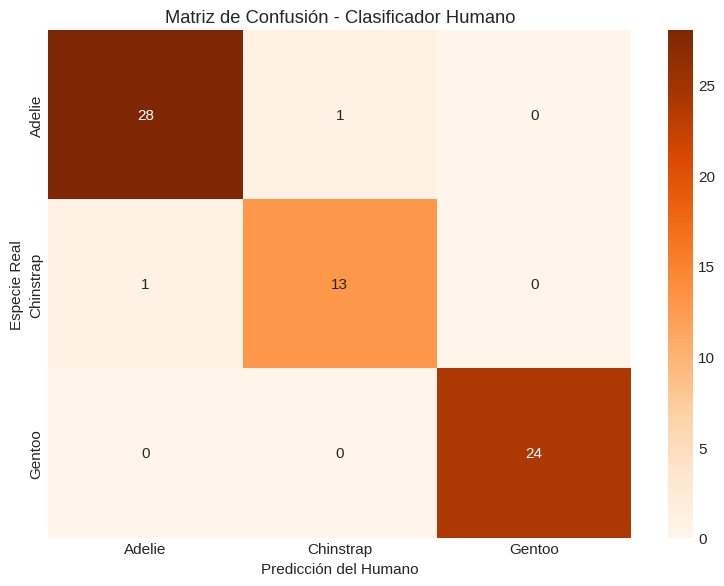


📊 Reporte Detallado:
              precision    recall  f1-score   support

      Adelie       0.97      0.97      0.97        29
   Chinstrap       0.93      0.93      0.93        14
      Gentoo       1.00      1.00      1.00        24

    accuracy                           0.97        67
   macro avg       0.96      0.96      0.96        67
weighted avg       0.97      0.97      0.97        67



In [ ]:
print("\n📋 Matriz de Confusión - Clasificador Humano Prueba 3:")
print("="*50)

cm_humano_prueba_3 = confusion_matrix(y_test, predicciones_humano_prueba_3, labels=['Adelie', 'Chinstrap', 'Gentoo'])

plt.figure(figsize=(8, 6))
sns.heatmap(cm_humano_prueba_3, annot=True, fmt='d', cmap='Oranges',
            xticklabels=['Adelie', 'Chinstrap', 'Gentoo'],
            yticklabels=['Adelie', 'Chinstrap', 'Gentoo'])
plt.xlabel('Predicción del Humano')
plt.ylabel('Especie Real')
plt.title('Matriz de Confusión - Clasificador Humano')
plt.tight_layout()
plt.savefig('confusion_humano_prueba_3.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n📊 Reporte Detallado:")
print(classification_report(y_test, predicciones_humano_prueba_3))

##Clasificador Definitivo

In [ ]:
def clasificador_humano_v2(
    bill_length_mm,
    bill_depth_mm,
    flipper_length_mm,
    body_mass_g):
  """
  Clasifica un pingüino basándose en reglas diseñadas por un humano.

  Cambios hechos:
  Se creó otro modelo inteligente, no se alteró el original; el proceso fue:
  - Primero se separa a Gentoo de otras clases debido a su facilidad para distinguirlo.
  - Cuando no fuera Gentoo, se buscó una forma de distinguir entre Adelie y Chinstrap.
  - Entre 40 y 46 de la variable bill_length_mm existe un conflicto entre Adelie y Chinstrap.
  - En esta zona se clasifica a Adélie debido a que tenía más presencia.
  - Se ajusta la condición de bill_length_mm > 46 a bill_length_mm > 45.

  Parámetros:
  -----------
  bill_length_mm : float
    Longitud del pico en milímetros
  bill_depth_mm : float
    Profundidad del pico en milímetros
  flipper_length_mm : float
    Longitud de la aleta en milímetros
  body_mass_g : float
    Masa corporal en gramos

  Retorna:
  --------
  str : 'Adelie', 'Chinstrap', o 'Gentoo'
  """

  if(flipper_length_mm > 200):
    if(bill_depth_mm < 18):
      return 'Gentoo'
    else:
      if bill_length_mm > 45:
        return 'Chinstrap'
      else:
        return 'Adelie'
  else:
    if bill_length_mm > 45:
      return 'Chinstrap'
    else:
      return 'Adelie'

In [ ]:
predicciones_humano_v2 = []

In [ ]:
for idx, row in X_test.iterrows():
    pred = clasificador_humano_v2(
        row['bill_length_mm'],
        row['bill_depth_mm'],
        row['flipper_length_mm'],
        row['body_mass_g']
    )
    predicciones_humano_v2.append(pred)

In [ ]:
accuracy_humano_v2 = accuracy_score(y_test, predicciones_humano_v2)


📋 Matriz de Confusión - Clasificador Humano v2:


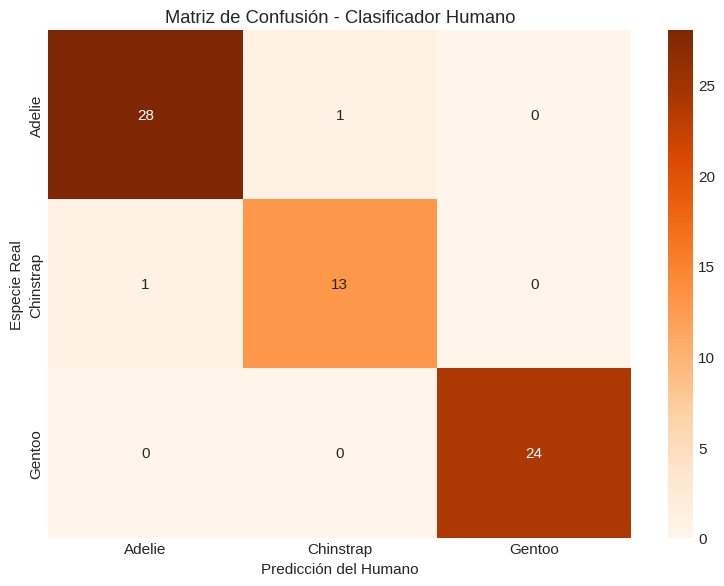


📊 Reporte Detallado:
              precision    recall  f1-score   support

      Adelie       0.97      0.97      0.97        29
   Chinstrap       0.93      0.93      0.93        14
      Gentoo       1.00      1.00      1.00        24

    accuracy                           0.97        67
   macro avg       0.96      0.96      0.96        67
weighted avg       0.97      0.97      0.97        67



In [ ]:
print("\n📋 Matriz de Confusión - Clasificador Humano v2:")
print("="*50)

cm_humano_v2 = confusion_matrix(y_test, predicciones_humano_prueba_3, labels=['Adelie', 'Chinstrap', 'Gentoo'])

plt.figure(figsize=(8, 6))
sns.heatmap(cm_humano_v2, annot=True, fmt='d', cmap='Oranges',
            xticklabels=['Adelie', 'Chinstrap', 'Gentoo'],
            yticklabels=['Adelie', 'Chinstrap', 'Gentoo'])
plt.xlabel('Predicción del Humano')
plt.ylabel('Especie Real')
plt.title('Matriz de Confusión - Clasificador Humano')
plt.tight_layout()
plt.savefig('confusion_humano_v2.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n📊 Reporte Detallado:")
print(classification_report(y_test, predicciones_humano_v2))

In [ ]:
print("╔═══════════════════════════════════════════════════════════════╗")
print("║        📈 RESULTADOS DEL CLASIFICADOR MEJORADO 📈            ║")
print("╠═══════════════════════════════════════════════════════════════╣")
print(f"║   Versión 1: {accuracy_humano:.2%}                                           ║")
print(f"║   Versión 2: {accuracy_humano_v2:.2%}                                           ║")
print(f"║   Mejora:    {(accuracy_humano_v2 - accuracy_humano):.2%}                                            ║")
print("╚═══════════════════════════════════════════════════════════════╝")

if accuracy_humano_v2 > accuracy_humano:
    print("\n🎉 ¡Excelente! Tu clasificador mejoró.")
else:
    print("\n🤔 Hmm, no hubo mejora. ¿Puedes intentar otros cambios?")

╔═══════════════════════════════════════════════════════════════╗
║        📈 RESULTADOS DEL CLASIFICADOR MEJORADO 📈            ║
╠═══════════════════════════════════════════════════════════════╣
║   Versión 1: 92.54%                                           ║
║   Versión 2: 97.01%                                           ║
║   Mejora:    4.48%                                            ║
╚═══════════════════════════════════════════════════════════════╝

🎉 ¡Excelente! Tu clasificador mejoró.


/tmp/ipython-input-3793163351.py:38: UserWarning: Glyph 128039 (\N{PENGUIN}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipython-input-3793163351.py:39: UserWarning: Glyph 128039 (\N{PENGUIN}) missing from font(s) Liberation Sans.
  plt.savefig('batalla_final_v2.png', dpi=150, bbox_inches='tight')
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128039 (\N{PENGUIN}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)


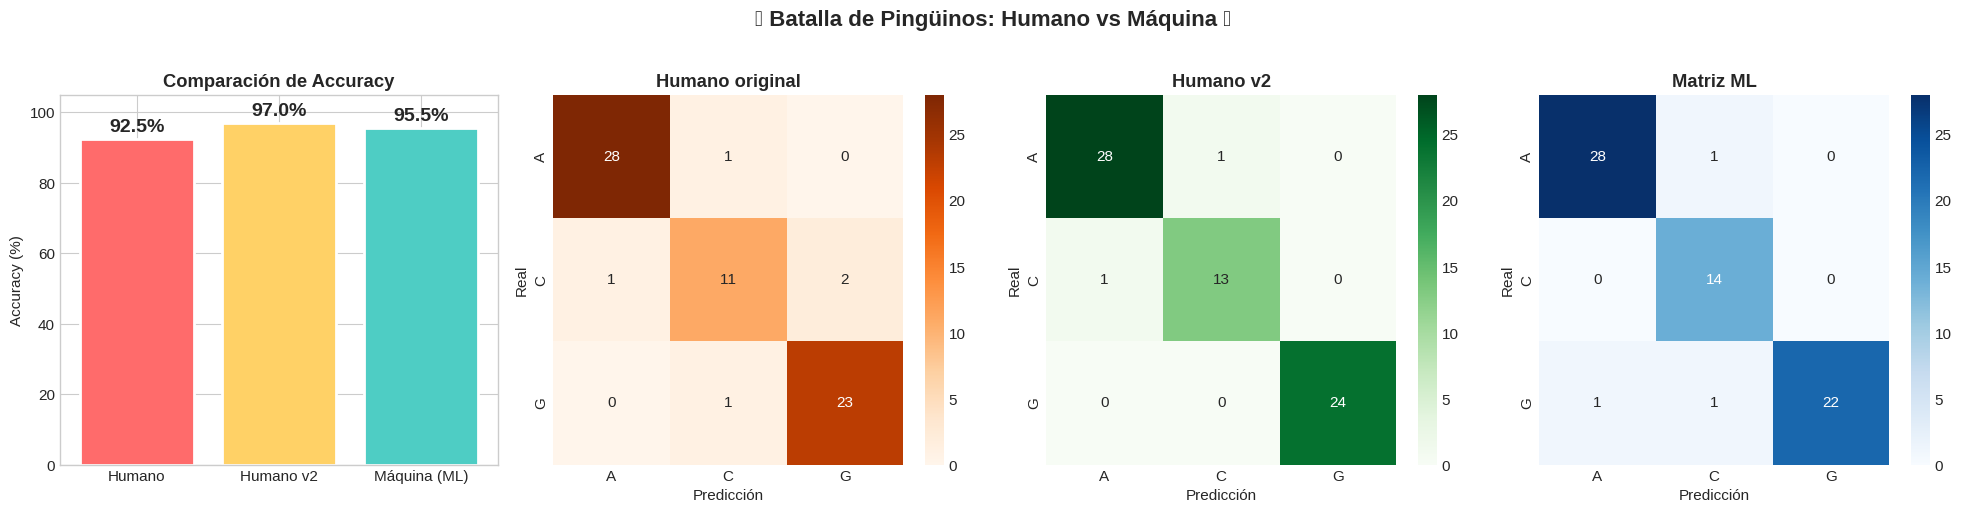

In [ ]:
fig, axes = plt.subplots(1, 4, figsize=(20, 5)) # Changed to 1 row, 4 columns, increased figsize

# Gráfica 1: Barras de accuracy
clasificadores = ['Humano', 'Humano v2', 'Máquina (ML)']
accuracies = [accuracy_humano * 100, accuracy_humano_v2 * 100, accuracy_ml * 100]
colores_barras = ['#FF6B6B', '#FFD166', '#4ECDC4'] # Añadido un color para Humano v2

bars = axes[0].bar(clasificadores, accuracies, color=colores_barras, edgecolor='white', linewidth=2)
axes[0].set_ylabel('Accuracy (%)')
axes[0].set_title('Comparación de Accuracy', fontweight='bold')
axes[0].set_ylim(0, 105)
for bar, acc in zip(bars, accuracies):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                f'{acc:.1f}%', ha='center', va='bottom', fontsize=14, fontweight='bold')

# Gráfica 2: Matrices de confusión lado a lado (Humano original)
sns.heatmap(cm_humano, annot=True, fmt='d', cmap='Oranges', ax=axes[1],
            xticklabels=['A', 'C', 'G'], yticklabels=['A', 'C', 'G'])
axes[1].set_title('Humano original', fontweight='bold') # Updated title
axes[1].set_xlabel('Predicción')
axes[1].set_ylabel('Real')

# Gráfica 3: Matriz Humano v2 (Nueva)
sns.heatmap(cm_humano_v2, annot=True, fmt='d', cmap='Greens', ax=axes[2], # Added new subplot
            xticklabels=['A', 'C', 'G'], yticklabels=['A', 'C', 'G'])
axes[2].set_title('Humano v2', fontweight='bold') # Title for the new subplot
axes[2].set_xlabel('Predicción')
axes[2].set_ylabel('Real')

# Gráfica 4: Matriz ML
sns.heatmap(cm_ml, annot=True, fmt='d', cmap='Blues', ax=axes[3],
            xticklabels=['A', 'C', 'G'], yticklabels=['A', 'C', 'G'])
axes[3].set_title('Matriz ML', fontweight='bold')
axes[3].set_xlabel('Predicción')
axes[3].set_ylabel('Real')

plt.suptitle('🐧 Batalla de Pingüinos: Humano vs Máquina 🐧', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('batalla_final_v2.png', dpi=150, bbox_inches='tight')
plt.show()

**Cambios hechos:**
<br>
Se creó otro modelo inteligente, no se alteró el original; el proceso fue:
- Primero se separa a Gentoo de otras clases debido a su facilidad para distinguirlo.
- Cuando no fuera Gentoo, se buscó una forma de distinguir entre Adelie y Chinstrap.
- Entre 40 y 46 de la variable bill_length_mm existe un conflicto entre Adelie y Chinstrap.
- En esta zona se clasifica a Adélie debido a que tenía más presencia.
- Se ajusta la condición de bill_length_mm > 46 a bill_length_mm > 45.